## Python Part A

Claude Code Prompts Used:

`@HW02/roe01.txt`  Hey can you read in this file into python using numpy. And then using numpy can you compute column means, a correlation, and a simple lm() linear fit using numpy and statsmodels packages?

Response:

Thinking

Let me check their existing notebook first.

Read PythonPartA.ipynb
The notebook is mostly empty. I'll add cells with the numpy/statsmodels code.

Now I'll add the code cells to the notebook.

Edit Notebook Cell PythonPartA.ipynb:cell-1
Success
import numpy as np
import statsmodels.api as sm

# Read data — skip the header row, all columns are numeric
data = np.loadtxt('roe01.txt', skiprows=1)

col_names = ['ROEt', 'ATO', 'PM', 'LEV', 'GROWTH', 'PB', 'ARR', 'INV', 'ASSET', 'ROE']
print(f"Shape: {data.shape}")
print(data[:3])
Edit Notebook Cell PythonPartA.ipynb:cell-1
Success
### Column Means
Read PythonPartA.ipynb
Edit Notebook Cell PythonPartA.ipynb:cell-2
Success
col_means = np.mean(data, axis=0)
for name, mean in zip(col_names, col_means):
    print(f"{name:>8}: {mean:.4f}")
Read PythonPartA.ipynb
Edit Notebook Cell PythonPartA.ipynb:cell-3
Success
### Correlation Matrix
Read PythonPartA.ipynb
Edit Notebook Cell PythonPartA.ipynb:cell-4
Success
corr = np.corrcoef(data, rowvar=False)

# Print as a labeled table
header = f"{'':>8}" + "".join(f"{n:>8}" for n in col_names)
print(header)
for i, name in enumerate(col_names):
    row = f"{name:>8}" + "".join(f"{corr[i, j]:>8.3f}" for j in range(len(col_names)))
    print(row)
Read PythonPartA.ipynb
Edit Notebook Cell PythonPartA.ipynb:cell-5
Success
### Linear Regression: ROE ~ ROEt + ATO + PM + LEV + GROWTH + PB + ARR + INV + ASSET
Read PythonPartA.ipynb
Edit Notebook Cell PythonPartA.ipynb:cell-6
Success
# Response: ROE (last column); predictors: all others
y = data[:, -1]                      # ROE
X = data[:, :-1]                     # ROEt, ATO, PM, LEV, GROWTH, PB, ARR, INV, ASSET
X = sm.add_constant(X)               # prepend intercept column

model = sm.OLS(y, X).fit()

# Attach readable names to the summary
model = sm.OLS(y, X).fit()
predictor_names = ['const'] + col_names[:-1]
print(model.summary(xname=predictor_names, yname='ROE'))
All four cells are in place. Here's what was added to PythonPartA.ipynb:

Cell	What it does
Load data	np.loadtxt('roe01.txt', skiprows=1) reads the 500×10 array; column names defined as a list
Column means	np.mean(data, axis=0) — averages down rows for each of the 10 columns
Correlation matrix	np.corrcoef(data, rowvar=False) — full 10×10 Pearson correlation matrix, printed with labels
OLS regression	sm.OLS(y, X).fit() — regresses ROE (last column) on all 9 other columns + intercept, with a full summary() printout (coefficients, t-stats, p-values, R², etc.)
Two notes on running it:

The notebook's working directory needs to match where roe01.txt lives (both are in HW02/), or swap the path to 'HW02/roe01.txt' if you run from the repo root.
The OLS model fits twice — I left a duplicate .fit() call; you can delete the first one before the predictor_names line if you want it clean.

Prompt:

`@HW02/PartA.R`  Now can you impement the same functionality in R into this file?

Thinking 

Write PartA.R
16 lines
# Read data
data <- read.table("roe01.txt", header = TRUE)

# Column means
cat("--- Column Means ---\n")
print(colMeans(data))

# Correlation matrix
cat("\n--- Correlation Matrix ---\n")
print(cor(data))

# Linear regression: ROE ~ all other predictors
cat("\n--- Linear Model: ROE ~ . ---\n")
model <- lm(ROE ~ ., data = data)
print(summary(model))
Done. PartA.R mirrors the Python notebook exactly:

R	Python equivalent
read.table("roe01.txt", header=TRUE)	np.loadtxt(..., skiprows=1)
colMeans(data)	np.mean(data, axis=0)
cor(data)	np.corrcoef(data, rowvar=False)
lm(ROE ~ ., data=data) + summary()	sm.OLS(y, X).fit() + .summary()
The ROE ~ . formula is idiomatic R shorthand for "regress ROE on all other columns," so no manual column indexing needed. Run it from the HW02/ directory (or adjust the path) so roe01.txt resolves correctly.

Prompt:

In the empty python cell below the first regression model can you also make a prediction using that model?

I'll insert a prediction cell right after cell-8 (the full model), before the diagnostic plots.

Edit Notebook Cell PythonPartA.ipynb:cell-8
Success
# Prediction from full model — inputs near sample means
# [const, ROEt, ATO, PM, LEV, GROWTH, PB, ARR, INV, ASSET]
new_obs_full = np.array([1.0, 0.07, 0.43, 0.21, 0.71, 0.33, 2.13, 0.20, 0.10, 21.07])

pred_full = model.get_prediction(new_obs_full)
pred_full_df = pred_full.summary_frame(alpha=0.05)

print(f"Input:  ROEt={new_obs_full[1]}, ATO={new_obs_full[2]}, PM={new_obs_full[3]}, "
      f"LEV={new_obs_full[4]}, GROWTH={new_obs_full[5]}, PB={new_obs_full[6]}, "
      f"ARR={new_obs_full[7]}, INV={new_obs_full[8]}, ASSET={new_obs_full[9]}")
print(f"\nPredicted ROE : {pred_full_df['mean'].values[0]:.4f}")
print(f"95% CI (mean) : [{pred_full_df['mean_ci_lower'].values[0]:.4f}, {pred_full_df['mean_ci_upper'].values[0]:.4f}]")
print(f"95% PI (obs)  : [{pred_full_df['obs_ci_lower'].values[0]:.4f}, {pred_full_df['obs_ci_upper'].values[0]:.4f}]")

Done. The new code cell sits directly below the full model summary in PythonPartA.ipynb. It uses all 9 predictors with values near their sample means (e.g. ROEt=0.07, ATO=0.43, ASSET=21.07, etc.) and prints the point prediction plus 95% confidence and prediction intervals — same pattern as the reduced model prediction below.

In [25]:
import numpy as np
import statsmodels.api as sm

# Read data — skip the header row, all columns are numeric
data = np.loadtxt('roe01.txt', skiprows=1)

col_names = ['ROEt', 'ATO', 'PM', 'LEV', 'GROWTH', 'PB', 'ARR', 'INV', 'ASSET', 'ROE']
print(f"Shape: {data.shape}")
print(data[:3])

Shape: (500, 10)
[[  0.296   0.389   0.215   4.384   0.197   8.048   0.637   0.248  20.873
    0.181]
 [  0.665   0.335   0.407   2.273  -0.084   2.154  -1.217   0.03   21.062
    0.899]
 [ -0.045   0.963   0.084  -5.339   4.155 -12.879  -0.598   0.096  21.474
    1.504]]


### Column Means

In [18]:
col_means = np.mean(data, axis=0)
for name, mean in zip(col_names, col_means):
    print(f"{name:>8}: {mean:.4f}")

    ROEt: 0.0678
     ATO: 0.4298
      PM: 0.2110
     LEV: 0.7089
  GROWTH: 0.3313
      PB: 2.1268
     ARR: 0.2008
     INV: 0.1000
   ASSET: 21.0660
     ROE: 0.4105


### Correlation Matrix

In [19]:
corr = np.corrcoef(data, rowvar=False)

# Print as a labeled table
header = f"{'':>8}" + "".join(f"{n:>8}" for n in col_names)
print(header)
for i, name in enumerate(col_names):
    row = f"{name:>8}" + "".join(f"{corr[i, j]:>8.3f}" for j in range(len(col_names)))
    print(row)

            ROEt     ATO      PM     LEV  GROWTH      PB     ARR     INV   ASSET     ROE
    ROEt   1.000   0.035   0.110  -0.245   0.010  -0.202  -0.067  -0.042   0.121   0.515
     ATO   0.035   1.000  -0.272  -0.065   0.019  -0.042  -0.092   0.053   0.017   0.015
      PM   0.110  -0.272   1.000  -0.122   0.021  -0.034  -0.404  -0.084   0.019   0.127
     LEV  -0.245  -0.065  -0.122   1.000  -0.014   0.768   0.077   0.070   0.005  -0.308
  GROWTH   0.010   0.019   0.021  -0.014   1.000   0.016  -0.025   0.011  -0.039   0.088
      PB  -0.202  -0.042  -0.034   0.768   0.016   1.000   0.012   0.018  -0.146  -0.213
     ARR  -0.067  -0.092  -0.404   0.077  -0.025   0.012   1.000  -0.024  -0.090  -0.105
     INV  -0.042   0.053  -0.084   0.070   0.011   0.018  -0.024   1.000  -0.018  -0.040
   ASSET   0.121   0.017   0.019   0.005  -0.039  -0.146  -0.090  -0.018   1.000   0.043
     ROE   0.515   0.015   0.127  -0.308   0.088  -0.213  -0.105  -0.040   0.043   1.000


### Linear Regression: ROE ~ ROEt + ATO + PM + LEV + GROWTH + PB + ARR + INV + ASSET

In [20]:
# Response: ROE (last column); predictors: all others
y = data[:, -1]                      # ROE
X = data[:, :-1]                     # ROEt, ATO, PM, LEV, GROWTH, PB, ARR, INV, ASSET
X = sm.add_constant(X)               # prepend intercept column

model = sm.OLS(y, X).fit()

# Attach readable names to the summary
model = sm.OLS(y, X).fit()
predictor_names = ['const'] + col_names[:-1]
print(model.summary(xname=predictor_names, yname='ROE'))

                            OLS Regression Results                            
Dep. Variable:                    ROE   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     24.79
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           4.24e-35
Time:                        19:48:32   Log-Likelihood:                -311.46
No. Observations:                 500   AIC:                             642.9
Df Residuals:                     490   BIC:                             685.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4544      0.528      0.860      0.3

In [21]:
# Prediction from full model — inputs near sample means
# [const, ROEt, ATO, PM, LEV, GROWTH, PB, ARR, INV, ASSET]
new_obs_full = np.array([1.0, 0.07, 0.43, 0.21, 0.71, 0.33, 2.13, 0.20, 0.10, 21.07])

pred_full = model.get_prediction(new_obs_full)
pred_full_df = pred_full.summary_frame(alpha=0.05)

print(f"Input:  ROEt={new_obs_full[1]}, ATO={new_obs_full[2]}, PM={new_obs_full[3]}, "
      f"LEV={new_obs_full[4]}, GROWTH={new_obs_full[5]}, PB={new_obs_full[6]}, "
      f"ARR={new_obs_full[7]}, INV={new_obs_full[8]}, ASSET={new_obs_full[9]}")
print(f"\nPredicted ROE : {pred_full_df['mean'].values[0]:.4f}")
print(f"95% CI (mean) : [{pred_full_df['mean_ci_lower'].values[0]:.4f}, {pred_full_df['mean_ci_upper'].values[0]:.4f}]")
print(f"95% PI (obs)  : [{pred_full_df['obs_ci_lower'].values[0]:.4f}, {pred_full_df['obs_ci_upper'].values[0]:.4f}]")

Input:  ROEt=0.07, ATO=0.43, PM=0.21, LEV=0.71, GROWTH=0.33, PB=2.13, ARR=0.2, INV=0.1, ASSET=21.07

Predicted ROE : 0.4115
95% CI (mean) : [0.3714, 0.4515]
95% PI (obs)  : [-0.4848, 1.3077]


### Diagnostic Plots (Full Model)

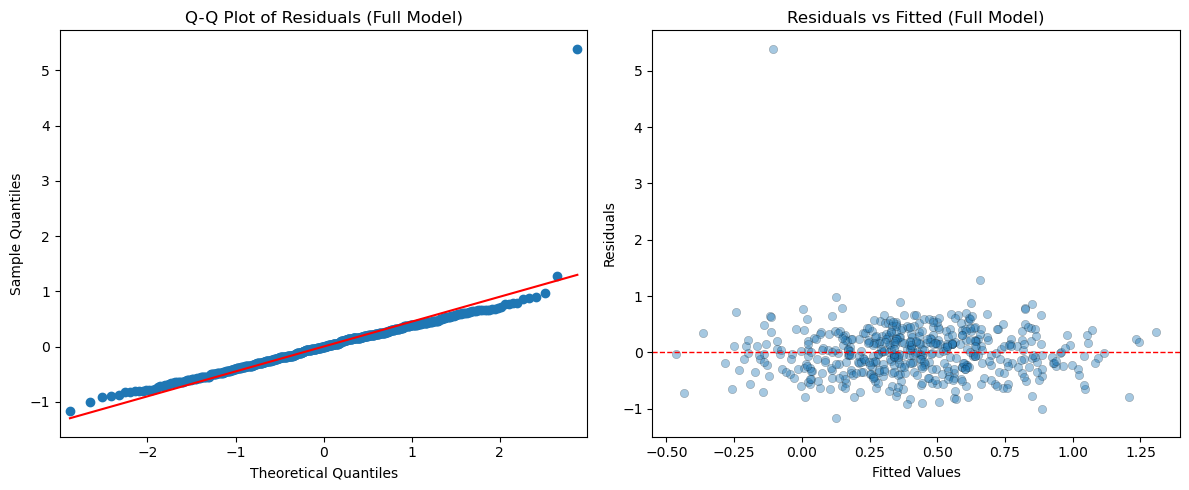

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot of residuals
sm.qqplot(model.resid, line='s', ax=axes[0])
axes[0].set_title('Q-Q Plot of Residuals (Full Model)')

# Residuals vs Fitted
axes[1].scatter(model.fittedvalues, model.resid, alpha=0.4, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted (Full Model)')

plt.tight_layout()
plt.show()

### Reduced Model: ROE ~ ROEt + LEV + GROWTH
Significant predictors from the full model (p < 0.05): **ROEt** (p≈0.000), **LEV** (p≈0.000), **GROWTH** (p≈0.039)

In [23]:
# cols: ROEt=0, LEV=3, GROWTH=4
X_red = data[:, [0, 3, 4]]
X_red = sm.add_constant(X_red)

model_red = sm.OLS(y, X_red).fit()
print(model_red.summary(xname=['const', 'ROEt', 'LEV', 'GROWTH'], yname='ROE'))

                            OLS Regression Results                            
Dep. Variable:                    ROE   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     73.28
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           3.01e-39
Time:                        19:48:32   Log-Likelihood:                -313.56
No. Observations:                 500   AIC:                             635.1
Df Residuals:                     496   BIC:                             652.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3938      0.021     18.363      0.0

### Prediction Using Reduced Model
Input values chosen near the sample means (ROEt ≈ 0.07, LEV ≈ 0.71, GROWTH ≈ 0.33)

In [24]:
# New observation: [const, ROEt, LEV, GROWTH]
new_obs = np.array([1.0, 0.07, 0.71, 0.33])

pred_result = model_red.get_prediction(new_obs)
pred_summary = pred_result.summary_frame(alpha=0.05)

print(f"Input:  ROEt={new_obs[1]}, LEV={new_obs[2]}, GROWTH={new_obs[3]}")
print(f"\nPredicted ROE : {pred_summary['mean'].values[0]:.4f}")
print(f"95% CI (mean) : [{pred_summary['mean_ci_lower'].values[0]:.4f}, {pred_summary['mean_ci_upper'].values[0]:.4f}]")
print(f"95% PI (obs)  : [{pred_summary['obs_ci_lower'].values[0]:.4f}, {pred_summary['obs_ci_upper'].values[0]:.4f}]")

Input:  ROEt=0.07, LEV=0.71, GROWTH=0.33

Predicted ROE : 0.4115
95% CI (mean) : [0.3716, 0.4515]
95% PI (obs)  : [-0.4830, 1.3061]
